# 04 · Agent Design Architectures

## 🎯 Goal

Compare two ways to organize one ecommerce agent: load focused Skills inside
one agent, or delegate work to specialist subagents.

## 🧰 Setup

The same customer request will be used for both designs.

In [1]:
from google.adk.agents import Agent
from google.adk.skills import load_skill_from_dir
from google.adk.tools.skill_toolset import SkillToolset
from workshop import (
    MODEL,
    ORDER_SKILL,
    STORE_SKILL,
    close_mcp_tools,
    get_store_hours,
    order_tools_from_mcp,
    run_agent,
    setup_workshop,
    show_comparison,
    show_text,
)

workshop = setup_workshop("agent-design-architectures")

✅ Workshop ready · Gemini configured · Phoenix tracing enabled


## Scenario

The customer asks one mixed question with two independent jobs: look up Store
hours and inspect an Order. We will answer it first with one shared Skills
context, then with a parent that delegates to focused specialists.

In [2]:
MIXED_PROMPT = (
    "When does Seattle Downtown close on Saturday?\n\n"
    "Also, find my most recent order from July 1 through July 31, 2026. "
    "Tell me its status, total, and "
    "every item's name and quantity."
)
show_text("Customer request", MIXED_PROMPT)

╭─────────────────────────────────────────────── Customer request ────────────────────────────────────────────────╮
│ When does Seattle Downtown close on Saturday?                                                                   │
│                                                                                                                 │
│ Also, find my most recent order from July 1 through July 31, 2026. Tell me its status, total, and every item's  │
│ name and quantity.                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

The customer does not ask for an architecture. Both implementations below
receive this exact same prompt so we can compare only how the work is organized.

In [3]:
SKILLS_INSTRUCTION = (
    "Help with order and store questions. Use the relevant available guidance "
    "and report only returned information."
)
ORDER_SPECIALIST_INSTRUCTION = (
    "Complete the delegated Order task with the available tools. "
    "Return one concise result using only returned information."
)
STORE_SPECIALIST_INSTRUCTION = (
    "Complete the delegated store-hours task with get_store_hours. "
    "Return one concise grounded result."
)
PARENT_INSTRUCTION = (
    "Delegate Order work to order_specialist and store-hours work to "
    "store_information_specialist, then combine their returned facts."
)

## Part A · One agent with Skills

Skill discovery stays light. The agent loads full Order or Store guidance only
when the request needs it. Everything still shares one agent context and loop.

▶️ Run the Skills design with the shared request. The design keeps one context
and adds reusable guidance on demand.

#### 🔎 Skills architecture



**What to notice**

One ecommerce agent owns the prompt, conversation history, and model loop. It starts with lightweight Skill descriptions and loads the selected Order or Store procedure and tools into that same context.

**Takeaway:** Choose Skills when one agent can own the work and should load detailed guidance only for the domains the current request needs.

In [4]:
# Load both reusable procedures for the mixed request.

order_skill = load_skill_from_dir(ORDER_SKILL.parent)
store_skill = load_skill_from_dir(STORE_SKILL.parent)

In [5]:
# Connect the focused Order MCP tools used by the Order Skill.

skills_order_tools = order_tools_from_mcp()

In [6]:
# Put both Skills and their domain tools behind one on-demand Skill interface.

ecommerce_skill_tools = SkillToolset(
    skills=[order_skill, store_skill],
    additional_tools=[skills_order_tools, get_store_hours],
)

In [7]:
# Give one agent ownership of the conversation and both procedures.
ecommerce_skills_agent = Agent(
    name="ecommerce_skills_agent",
    model=MODEL,
    instruction=SKILLS_INSTRUCTION,
    tools=[ecommerce_skill_tools],
)

In [8]:
# Run the shared request through the Skills architecture.
skills_result = await run_agent(
    ecommerce_skills_agent,
    MIXED_PROMPT,
    session_id="04-a-ecommerce-skills",
    trace_name="04-a-ecommerce-skills",
)

The Seattle Downtown store closes at 8:00 PM on Saturdays.

Your most recent order between July 1 and July 31, 2026, is order **WM-DEMO-1004** (placed on 2026-07-19).

*   **Status:** processing
*   **Total:** 291.00 USD

**Items in this order:**
1.  **Ninja Foodi 6-in-1, 8 Quart 2-Basket Air Fryer with DualZone Technology -White**: 1
2.  **Ninja Nutri-Blender Pro with Auto-iQ, Personal Blender, CL401A**: 1


🔎 [Open this exact trace in Phoenix](https://app.phoenix.arize.com/s/adk-demo-search/redirects/traces/775404cfdbcf31b05bf33ee02c03977b)

#### 🔎 Skills architecture fallback trace

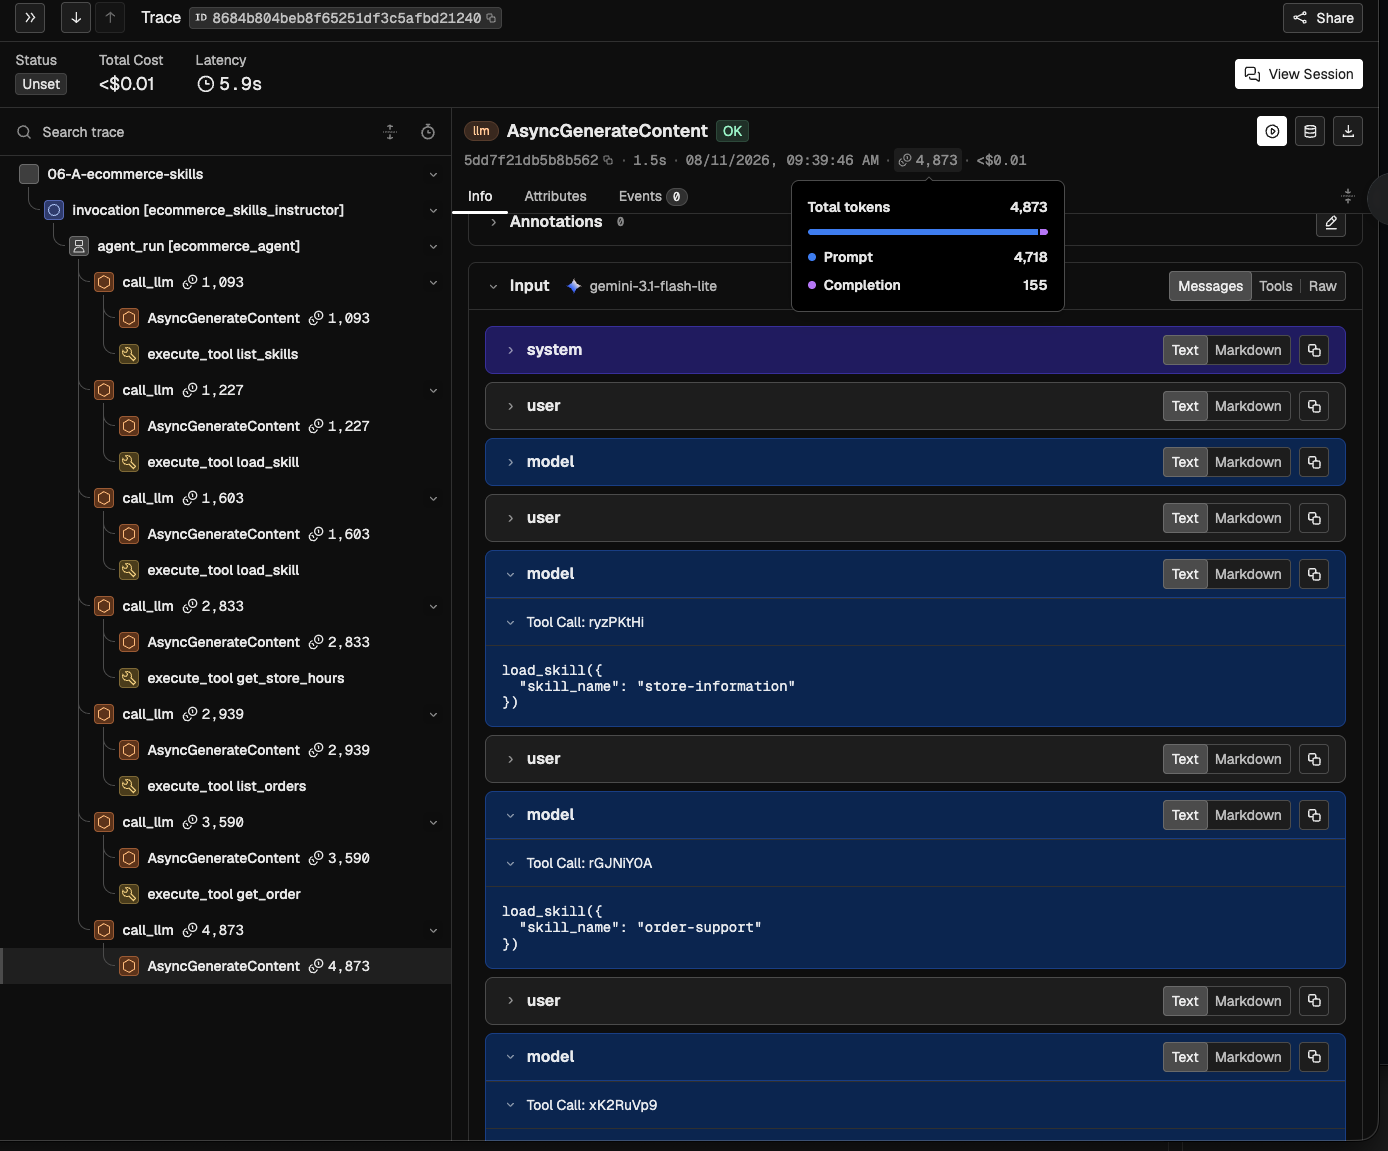

**What to notice**

One agent owns the conversation and loads both procedures. The selected guidance and tool results share its context.

**Takeaway:** Skills focus one agent without creating another model boundary, but loaded guidance and results still accumulate in one shared context.

## ✅ Checkpoint

Nice work—you kept one agent and added reusable guidance only when needed.

## Part B · Parent with specialist subagents

Each specialist gets its own prompt, tools, context, and loop. The parent owns
the customer conversation and combines the bounded results.

#### 🔎 Subagent architecture



**What to notice**

The parent sees the Order and Store specialists as two callable tools. Each specialist receives only its delegated question and runs with its own instruction, focused tools, context, and model loop.

**Takeaway:** Choose subagents when a domain benefits from an isolated working context and the extra model boundary is worth the ownership and separation.

In [9]:
# Give the parent focused specialists, starting with the Order domain.
# Build the Order specialist with only the Order MCP tools.
subagent_order_tools = order_tools_from_mcp()
order_specialist = Agent(
    name="order_specialist",
    model=MODEL,
    mode="single_turn",
    instruction=ORDER_SPECIALIST_INSTRUCTION,
    tools=[subagent_order_tools],
)

In [10]:
# Build the Store specialist with only the local store-hours tool.
store_information_specialist = Agent(
    name="store_information_specialist",
    model=MODEL,
    mode="single_turn",
    instruction=STORE_SPECIALIST_INSTRUCTION,
    tools=[get_store_hours],
)

In [11]:
# Give the parent both specialists; ADK exposes each one as a callable tool.
ecommerce_parent = Agent(
    name="ecommerce_agent",
    model=MODEL,
    instruction=PARENT_INSTRUCTION,
    sub_agents=[order_specialist, store_information_specialist],
)

In [12]:
# Run the same request through the parent and its specialists.
subagent_result = await run_agent(
    ecommerce_parent,
    MIXED_PROMPT,
    session_id="04-b-ecommerce-subagents",
    trace_name="04-b-ecommerce-subagents",
)

The Seattle Downtown store closes at 8:00 PM on Saturdays.

Regarding your order history, your most recent order from July 2026 is as follows:

*   **Order Number:** WM-DEMO-1004 (Placed on July 19, 2026)
*   **Status:** Processing
*   **Total:** $291.00 USD
*   **Items:**
    *   **Ninja Foodi 6-in-1, 8 Quart 2-Basket Air Fryer with DualZone Technology - White:** 1
    *   **Ninja Nutri-Blender Pro with Auto-iQ, Personal Blender, CL401A:** 1


🔎 [Open this exact trace in Phoenix](https://app.phoenix.arize.com/s/adk-demo-search/redirects/traces/8851cfaa5e583e6299f1c7c6f1d7c735)

#### 🔎 Subagents: compact overview

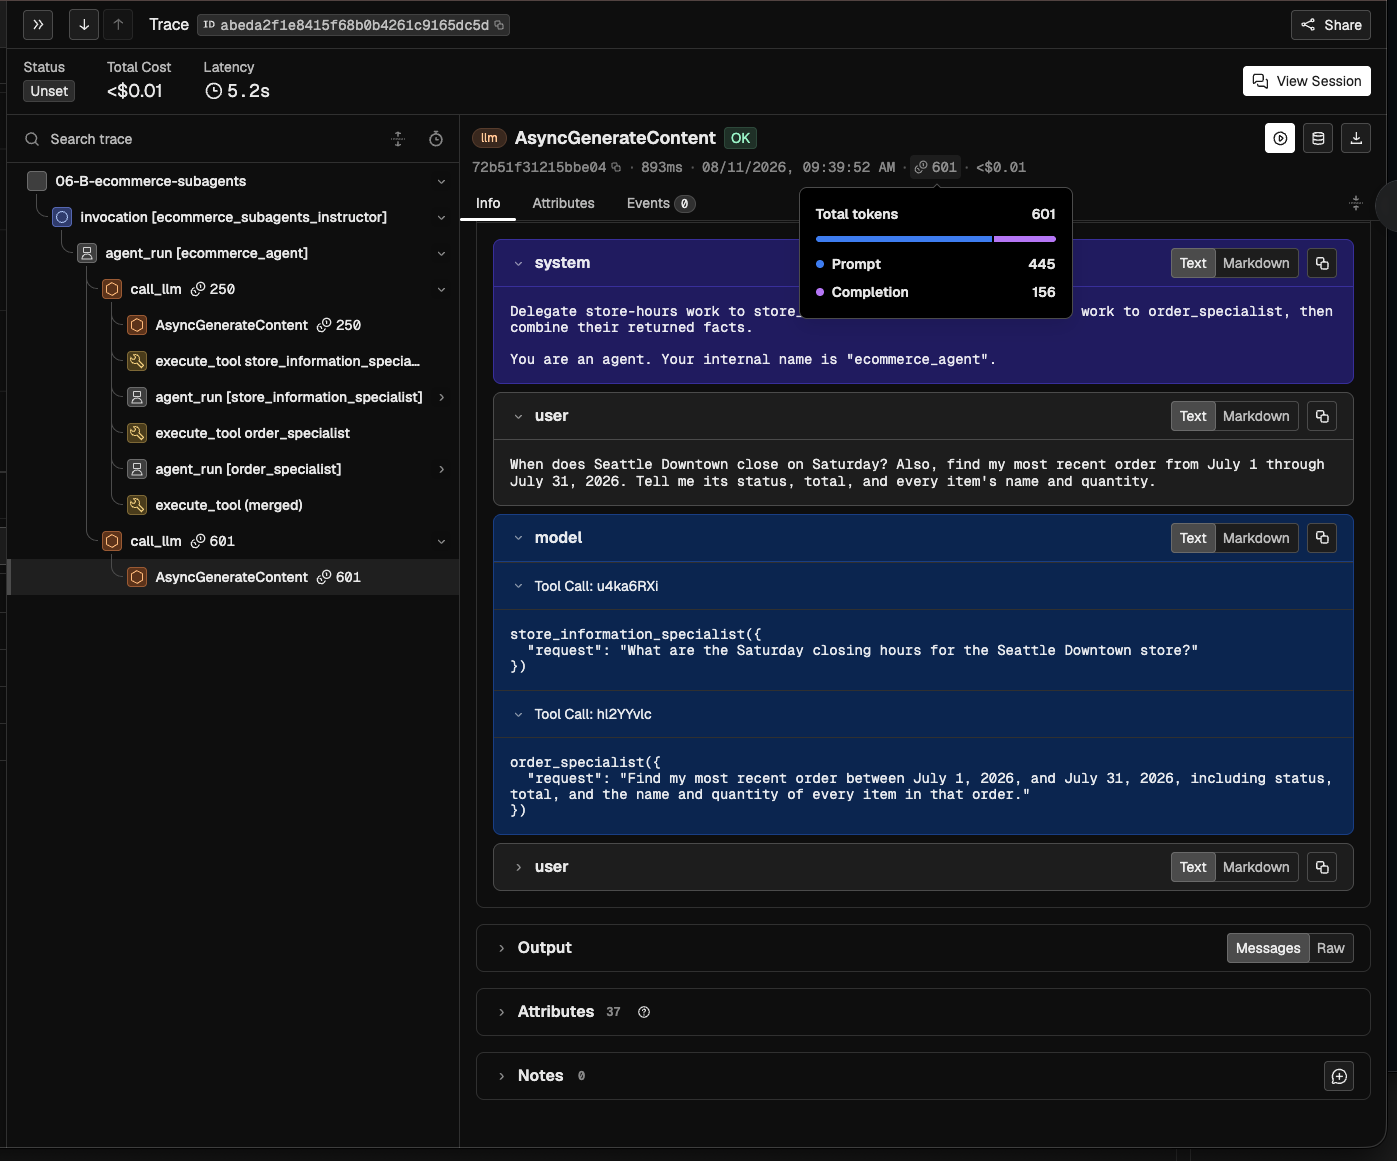

**What to notice**

The parent delegates two bounded jobs. Each specialist reasons in a separate context, then returns a concise result.

**Takeaway:** The parent receives compact domain answers instead of inheriting both specialists' full working histories.

#### 🔎 Parent tool definitions

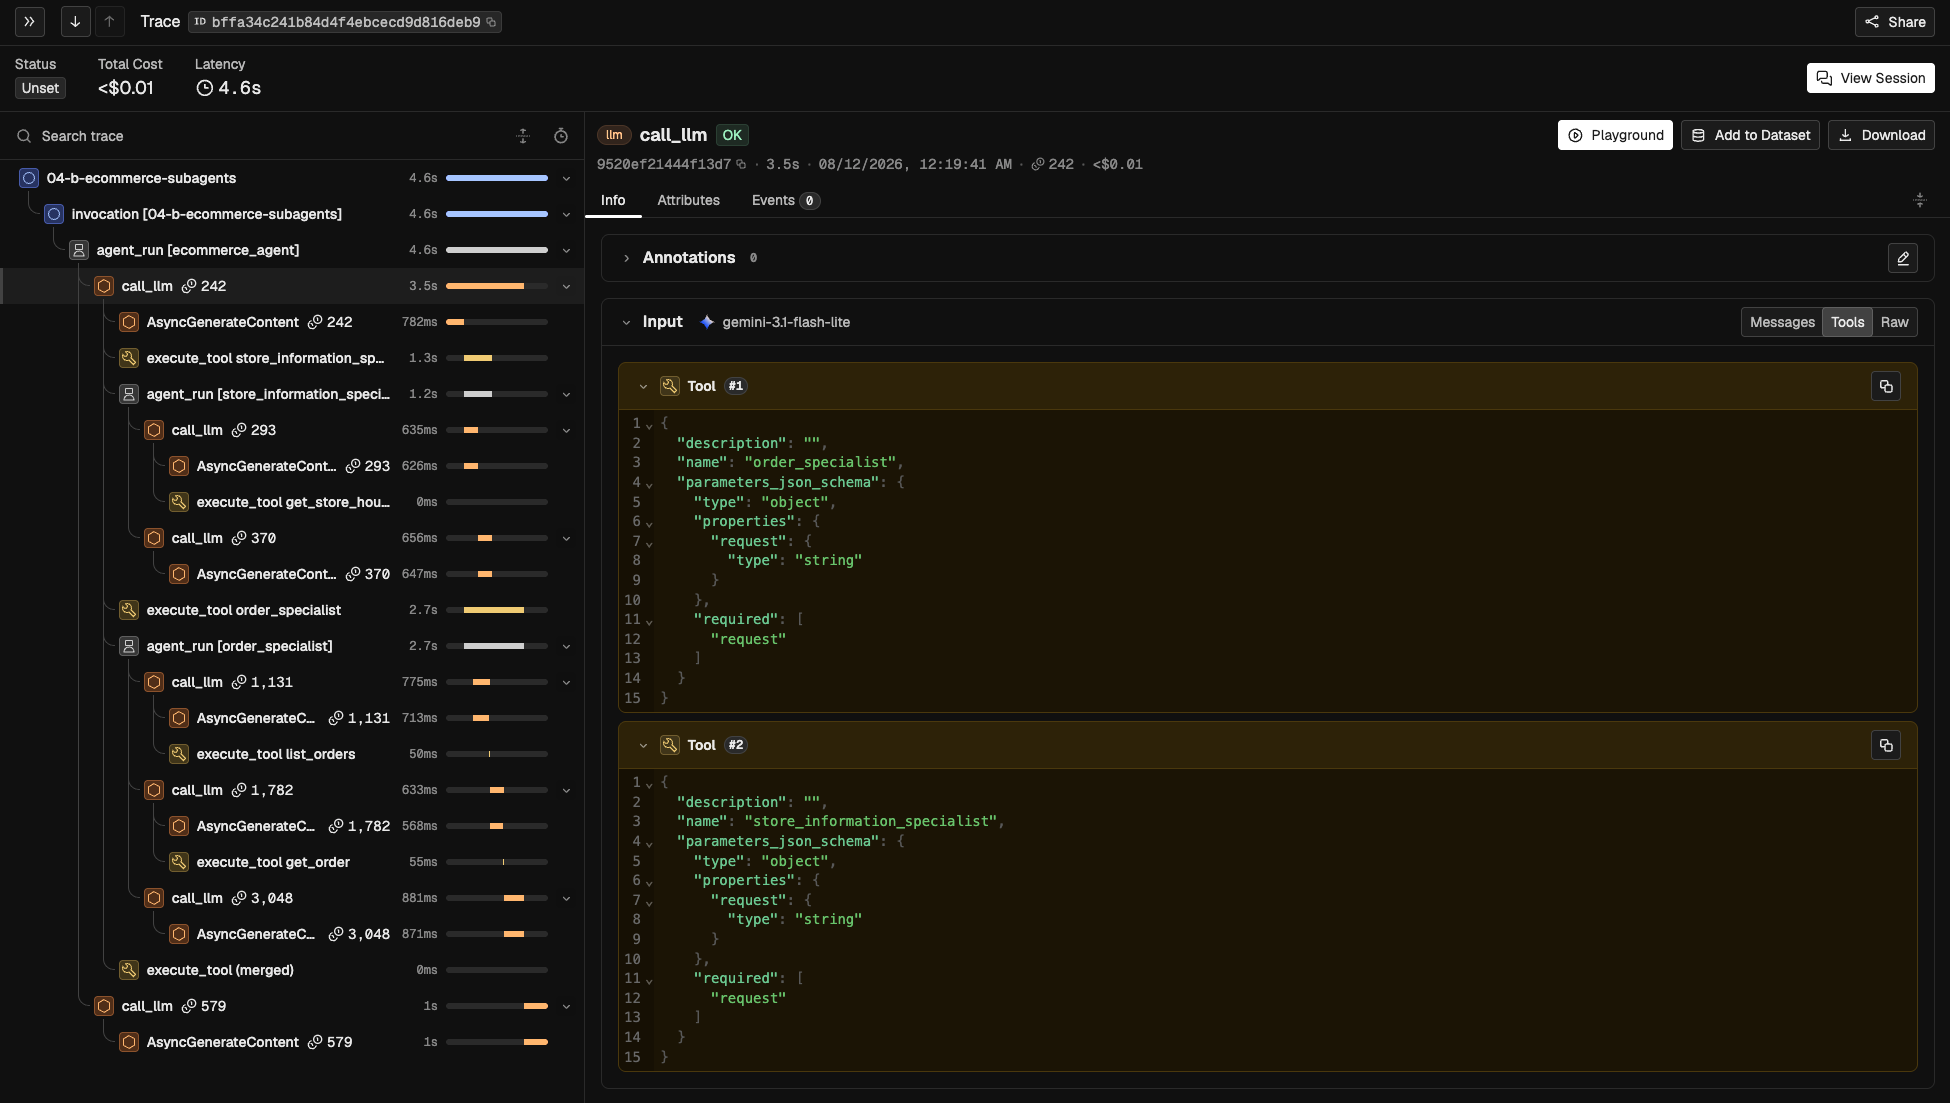

**What to notice**

The parent sees each subagent as a tool with one bounded `request` argument. It does not receive the specialists' internal Order or Store tools.

**Takeaway:** A subagent is a callable model boundary: the parent chooses the specialist, while the specialist chooses its own internal tools.

#### 🔎 Two calls emitted together

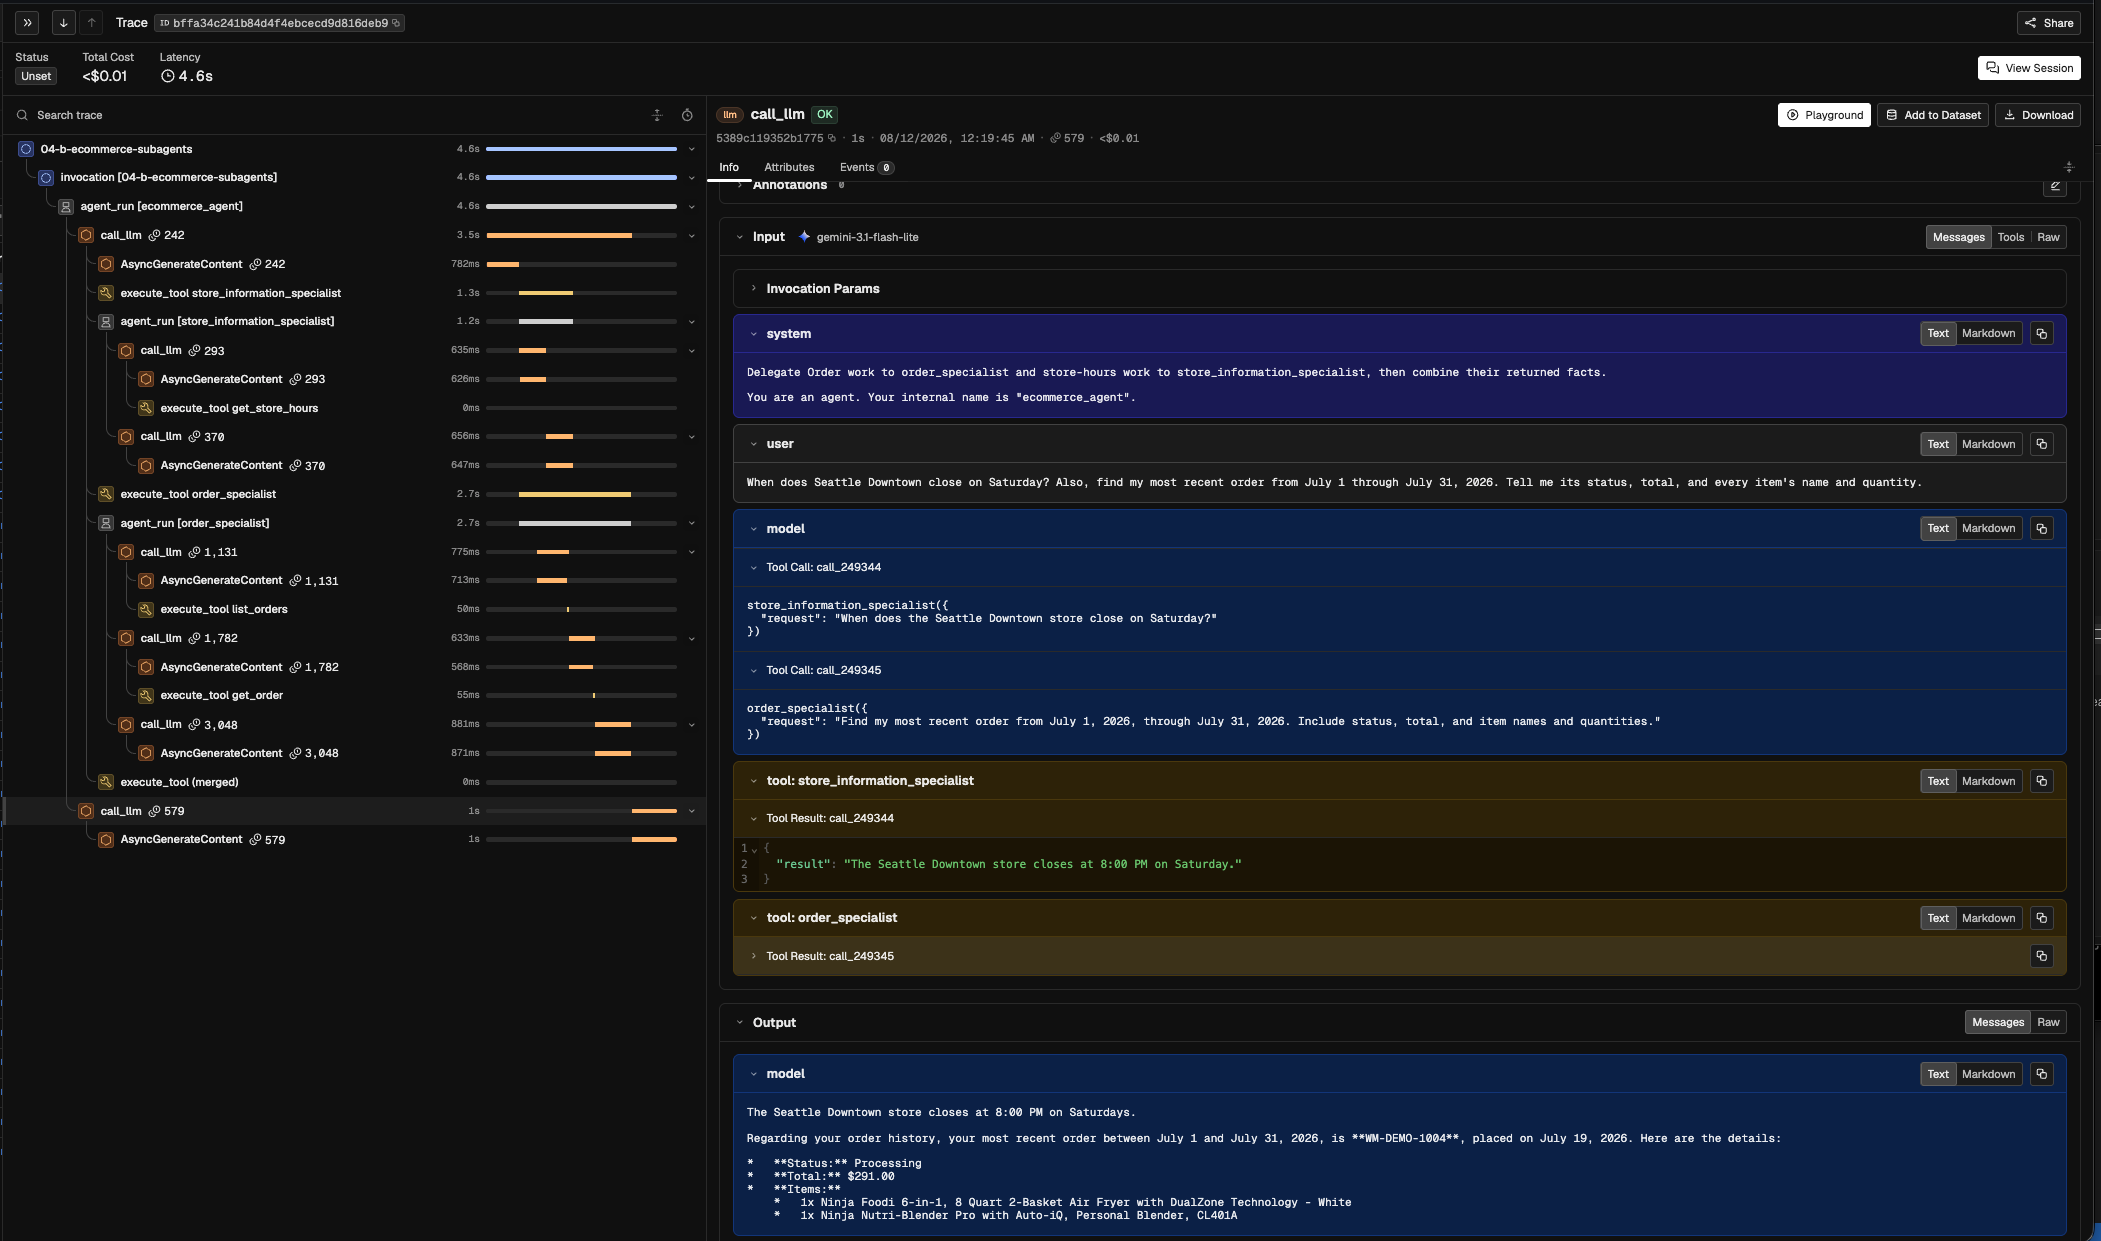

**What to notice**

The parent's first model response contains both specialist calls. Because the Store and Order jobs are independent and appear in the same model response, ADK can execute them concurrently before the parent combines their results.

**Takeaway:** Parallel delegation can reduce elapsed time when the two jobs do not depend on each other's output.

Each specialist has its own instruction, tools, context, and model loop. The
next views open those two bounded calls so we can see the isolation clearly.

#### 🔎 Store specialist boundary

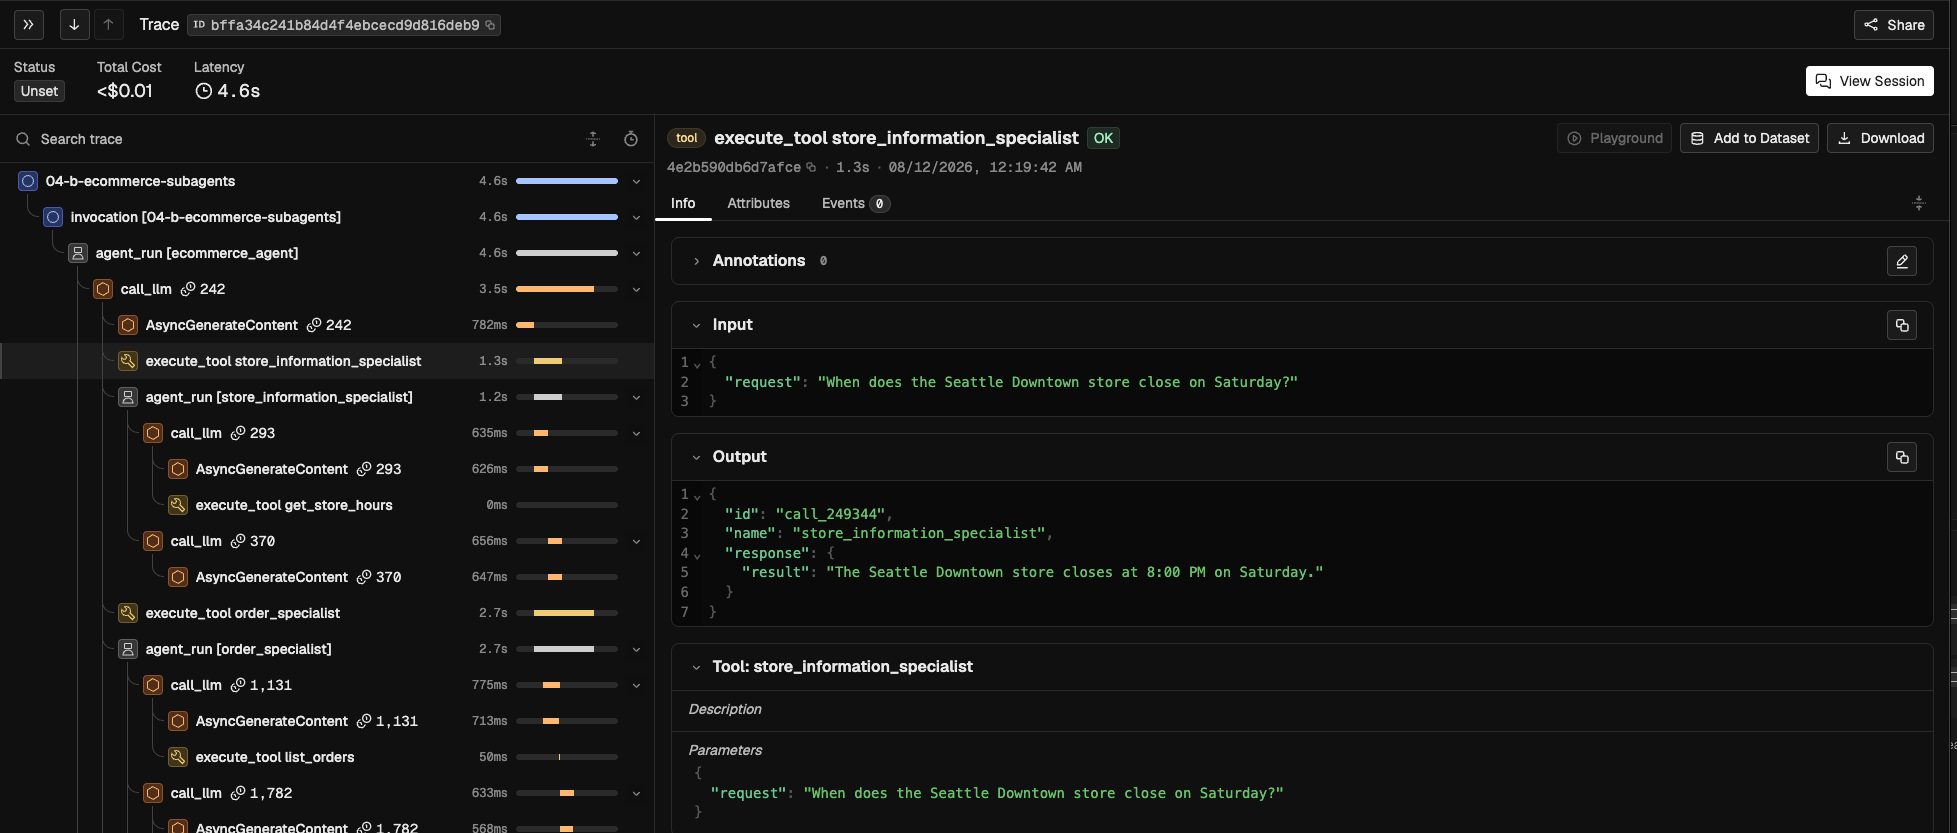

**What to notice**

The parent sends only the Store portion of the request. The specialist returns one concise result to the parent.

**Takeaway:** Delegation narrows the job before the specialist starts reasoning.

#### 🔎 Store specialist tools

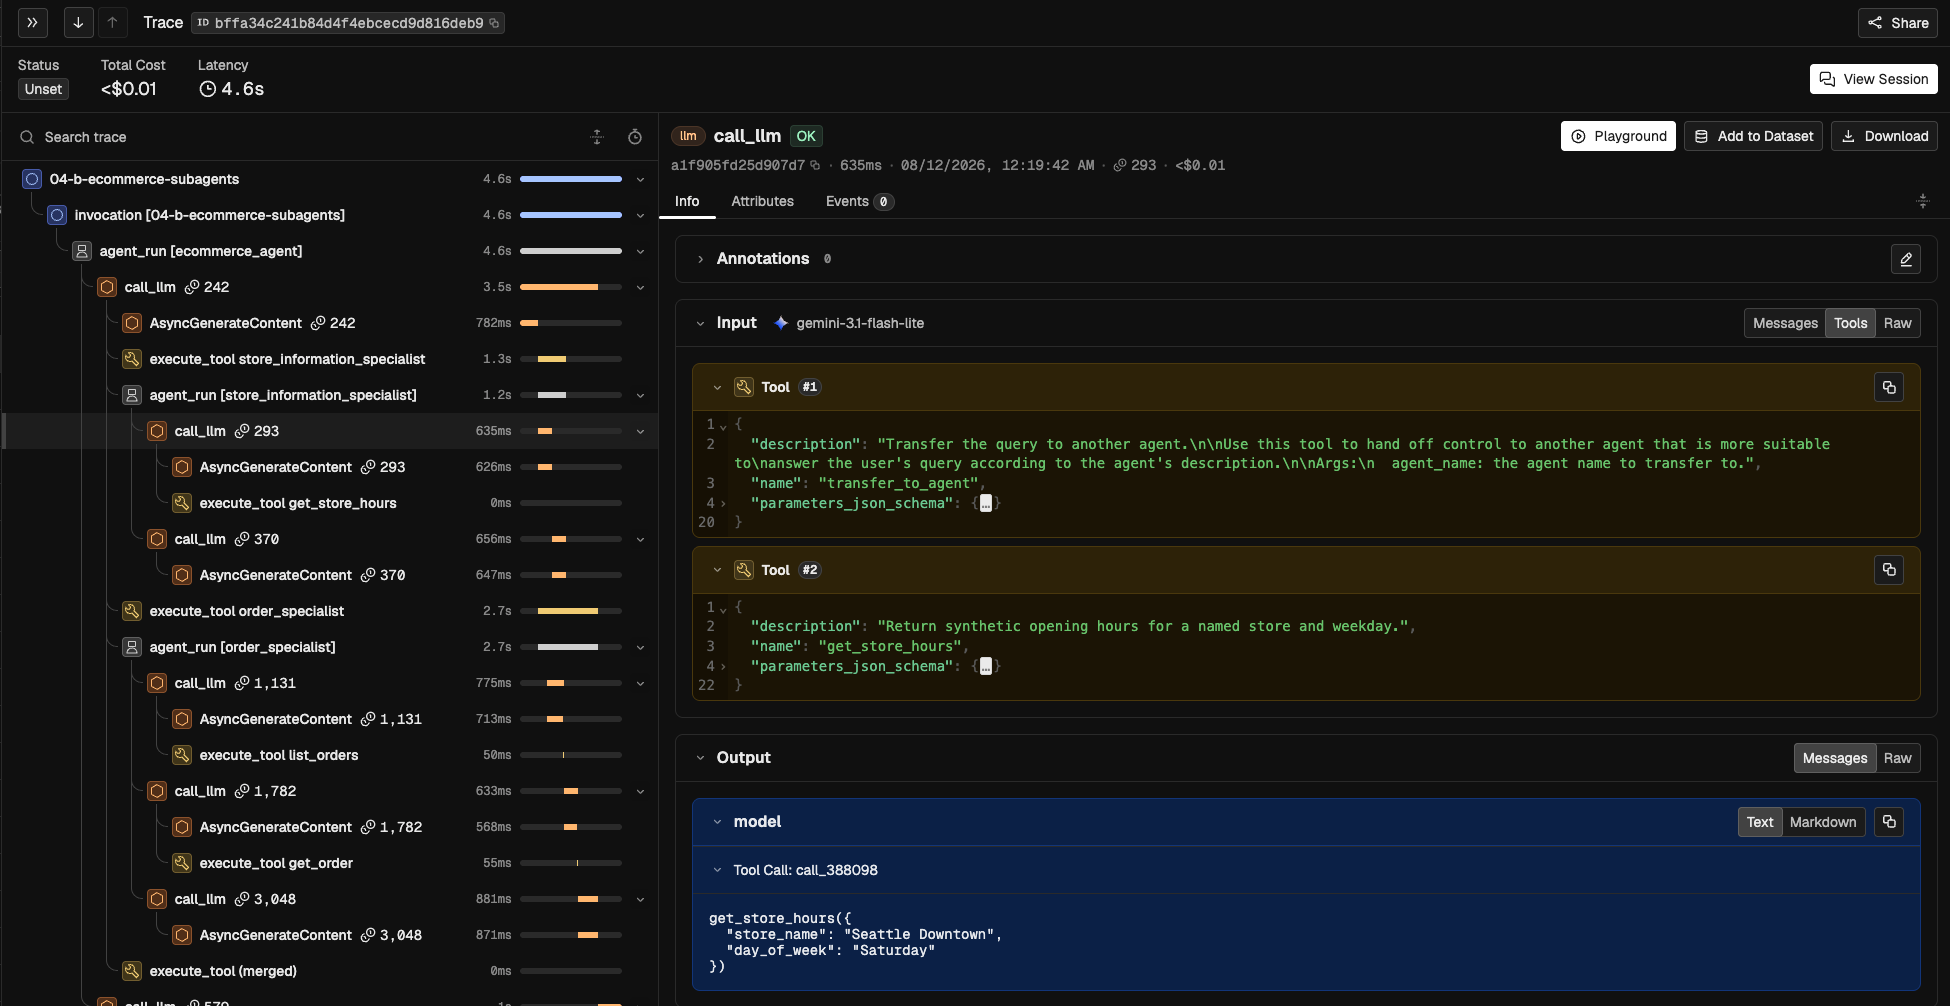

**What to notice**

Inside its own context, the Store specialist sees `get_store_hours` plus ADK's transfer tool—not the Order tools.

**Takeaway:** Focused tool access reduces irrelevant schemas and makes domain ownership explicit.

#### 🔎 Store specialist instruction

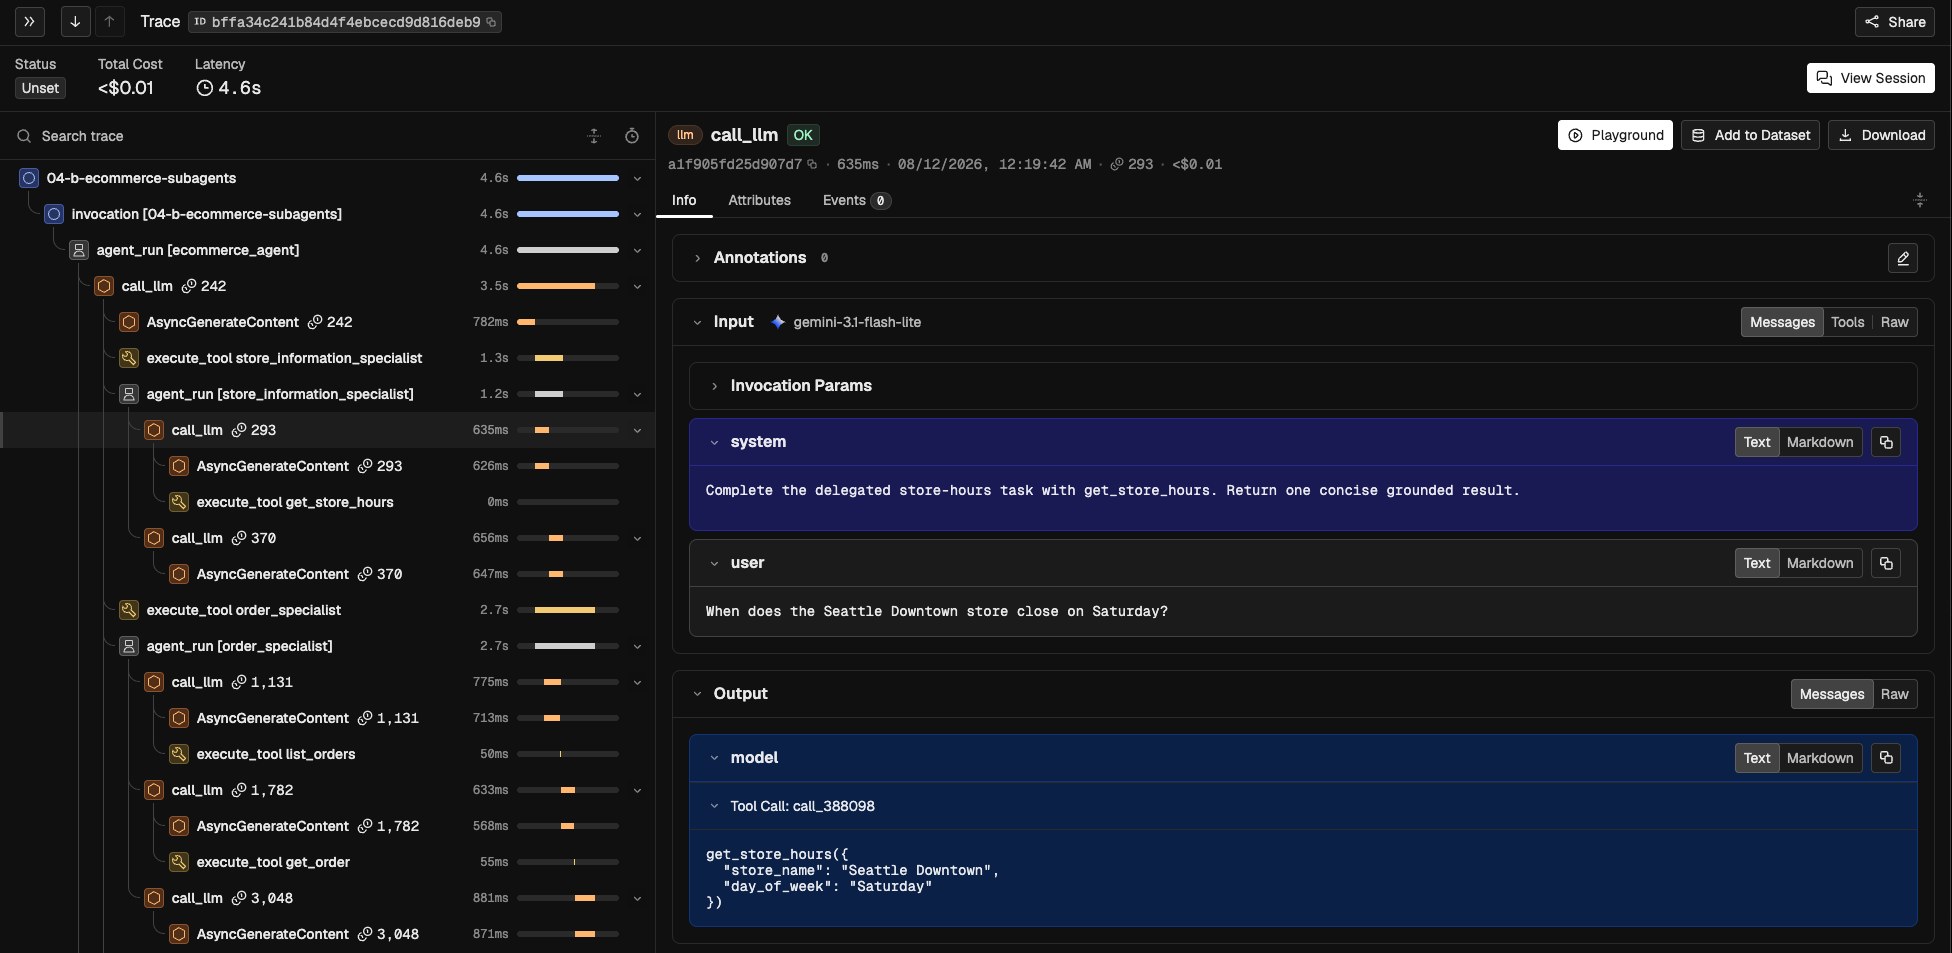

**What to notice**

The Store specialist receives a focused system instruction and only the delegated Store question.

**Takeaway:** The specialist does not need the customer's unrelated Order request in its working context.

#### 🔎 Store specialist grounded result

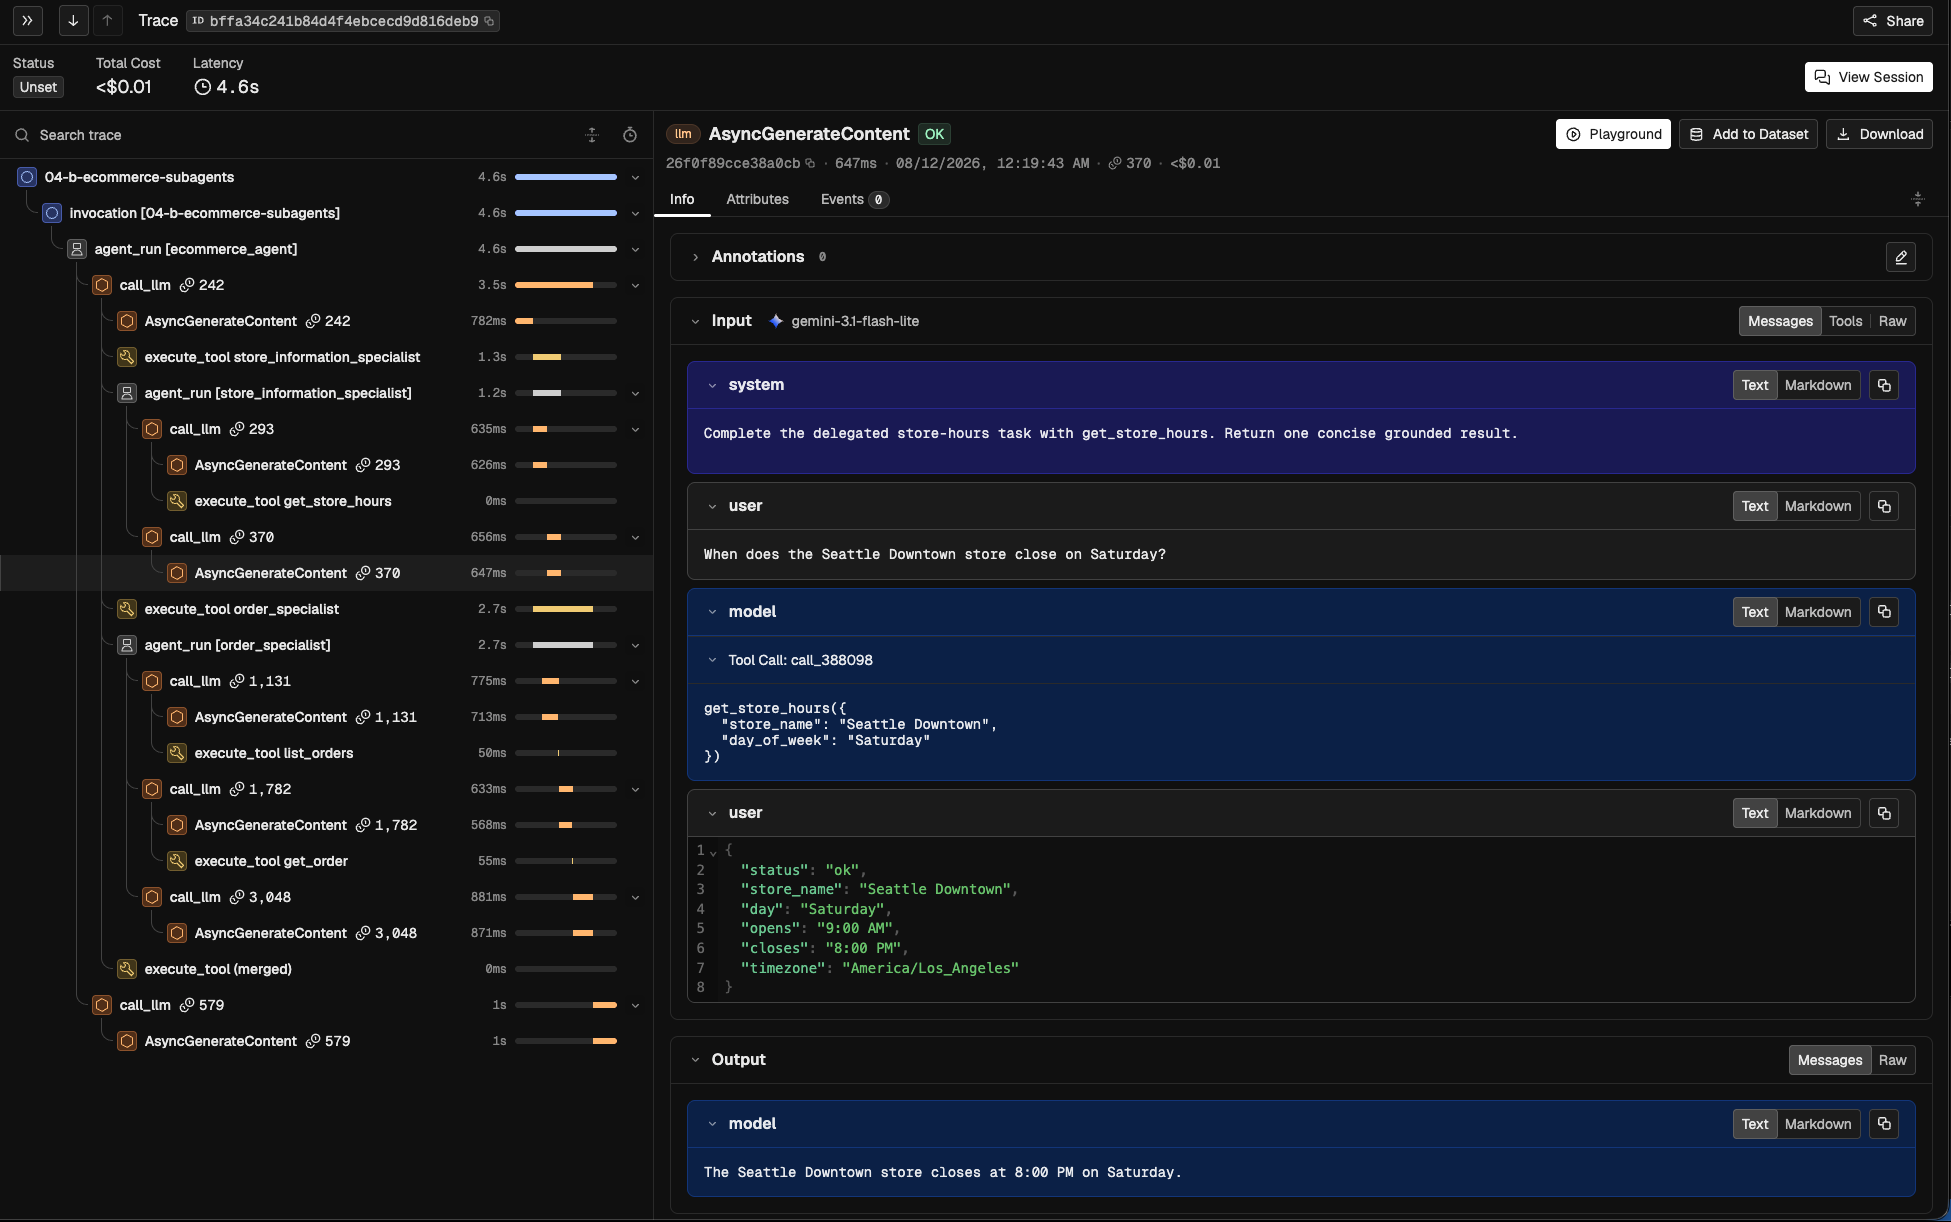

**What to notice**

Its tool result is appended to the specialist's message history, then its second model call writes the bounded answer returned to the parent.

**Takeaway:** The familiar model → tool → model loop happens inside the specialist boundary.

#### 🔎 Order specialist boundary

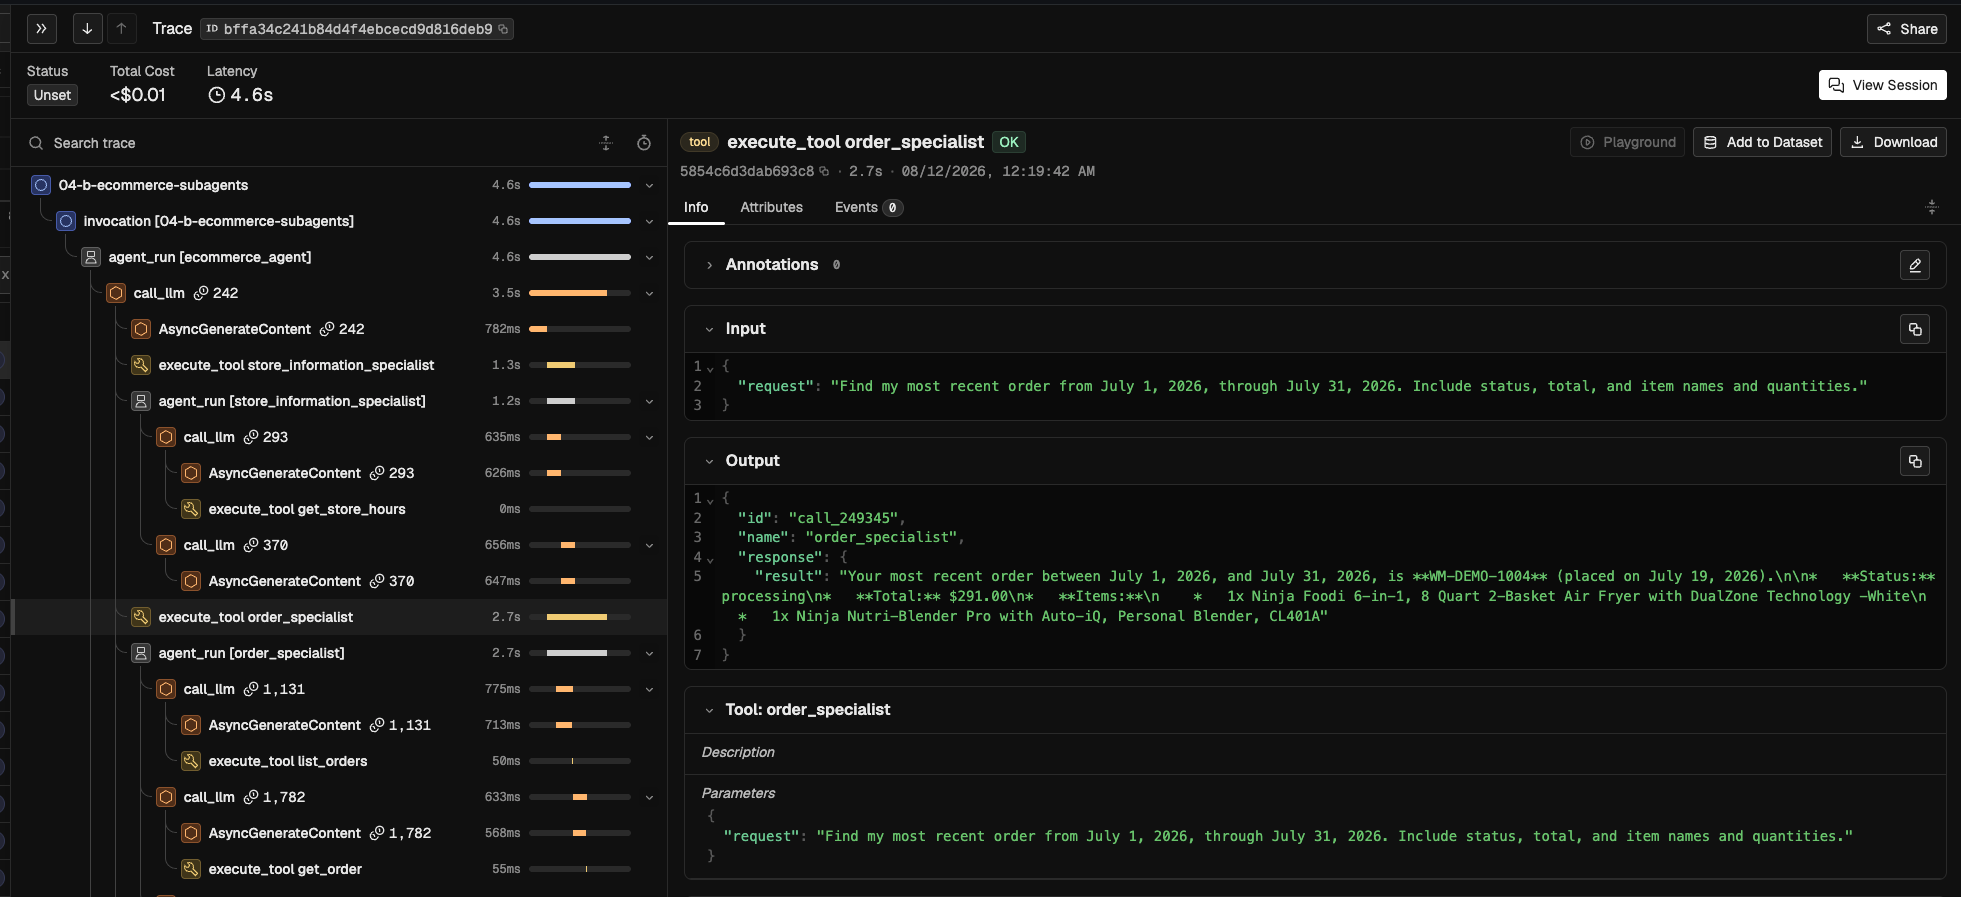

**What to notice**

The parent sends only the Order portion of the request. The specialist performs the full Order workflow and returns a bounded answer.

**Takeaway:** The parent gets the answer it needs without carrying the specialist's intermediate order summaries and details.

#### 🔎 Order specialist instruction

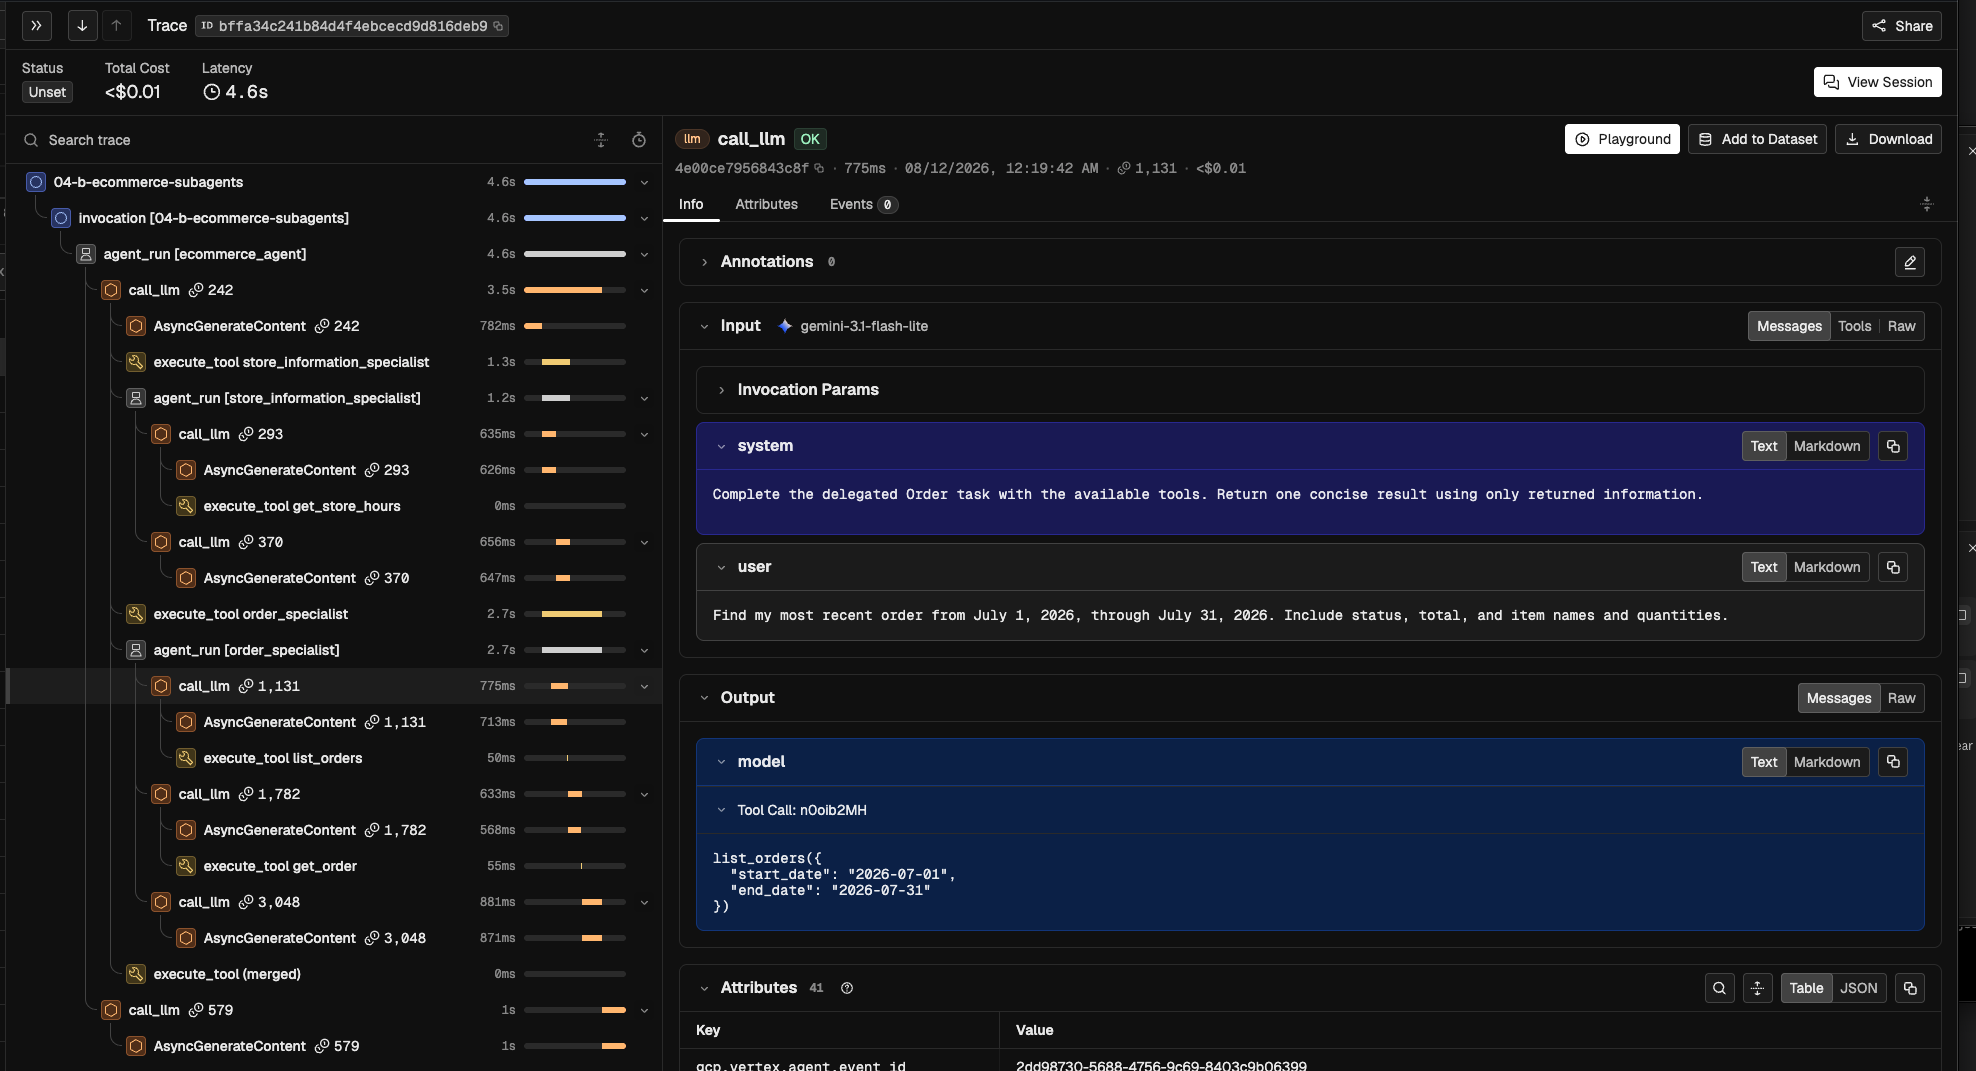

**What to notice**

The Order specialist gets its own grounding instruction and the delegated Order question.

**Takeaway:** A separate instruction lets the Order domain evolve without expanding the parent's prompt.

#### 🔎 Order specialist working context

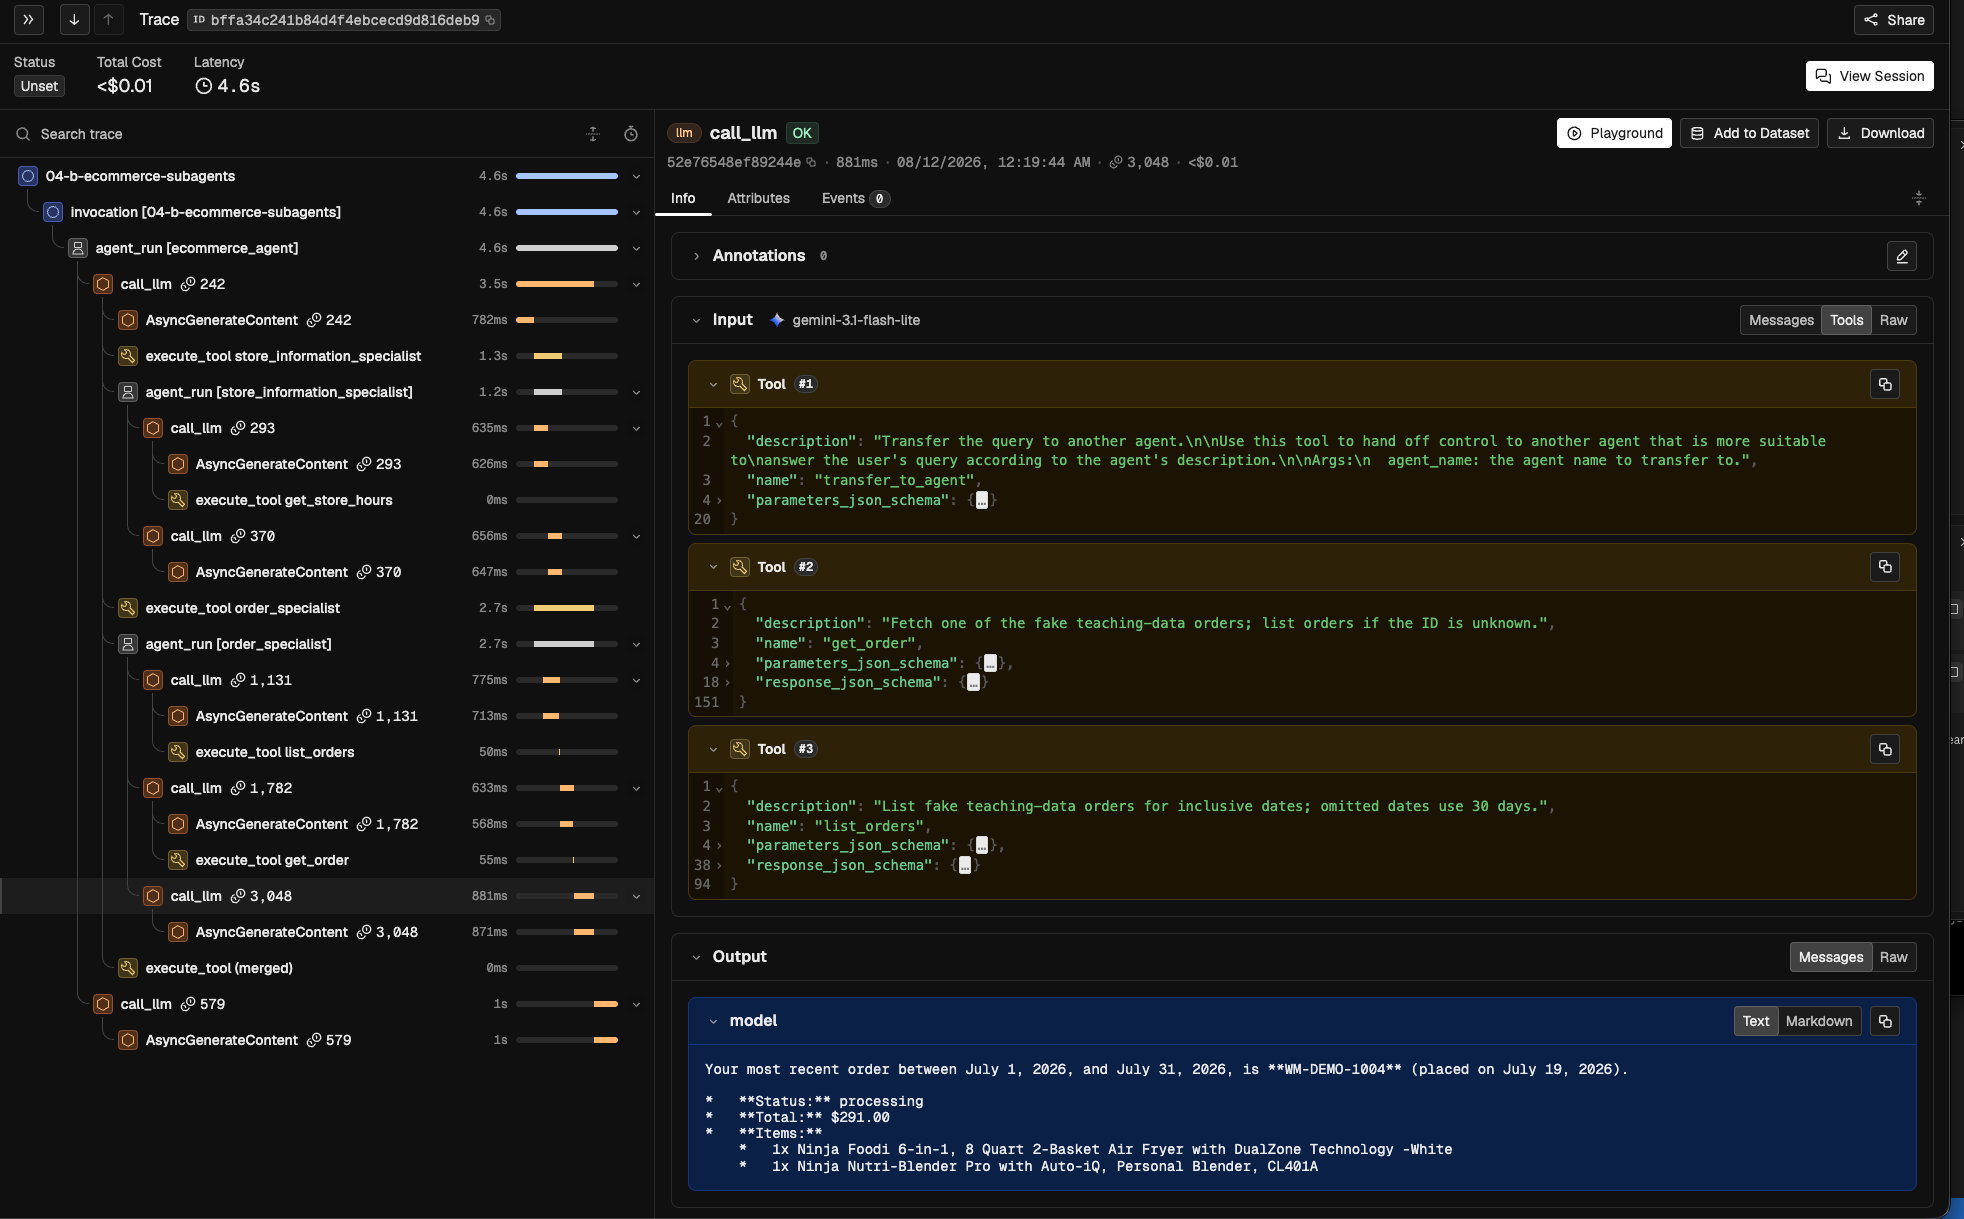

**What to notice**

Within its isolated context, the specialist calls `list_orders`, preserves a returned ID, calls `get_order`, and writes its own grounded result.

**Takeaway:** All multi-step Order evidence stays inside the Order specialist until its concise result is ready.

#### 🔎 Parent receives the bounded results

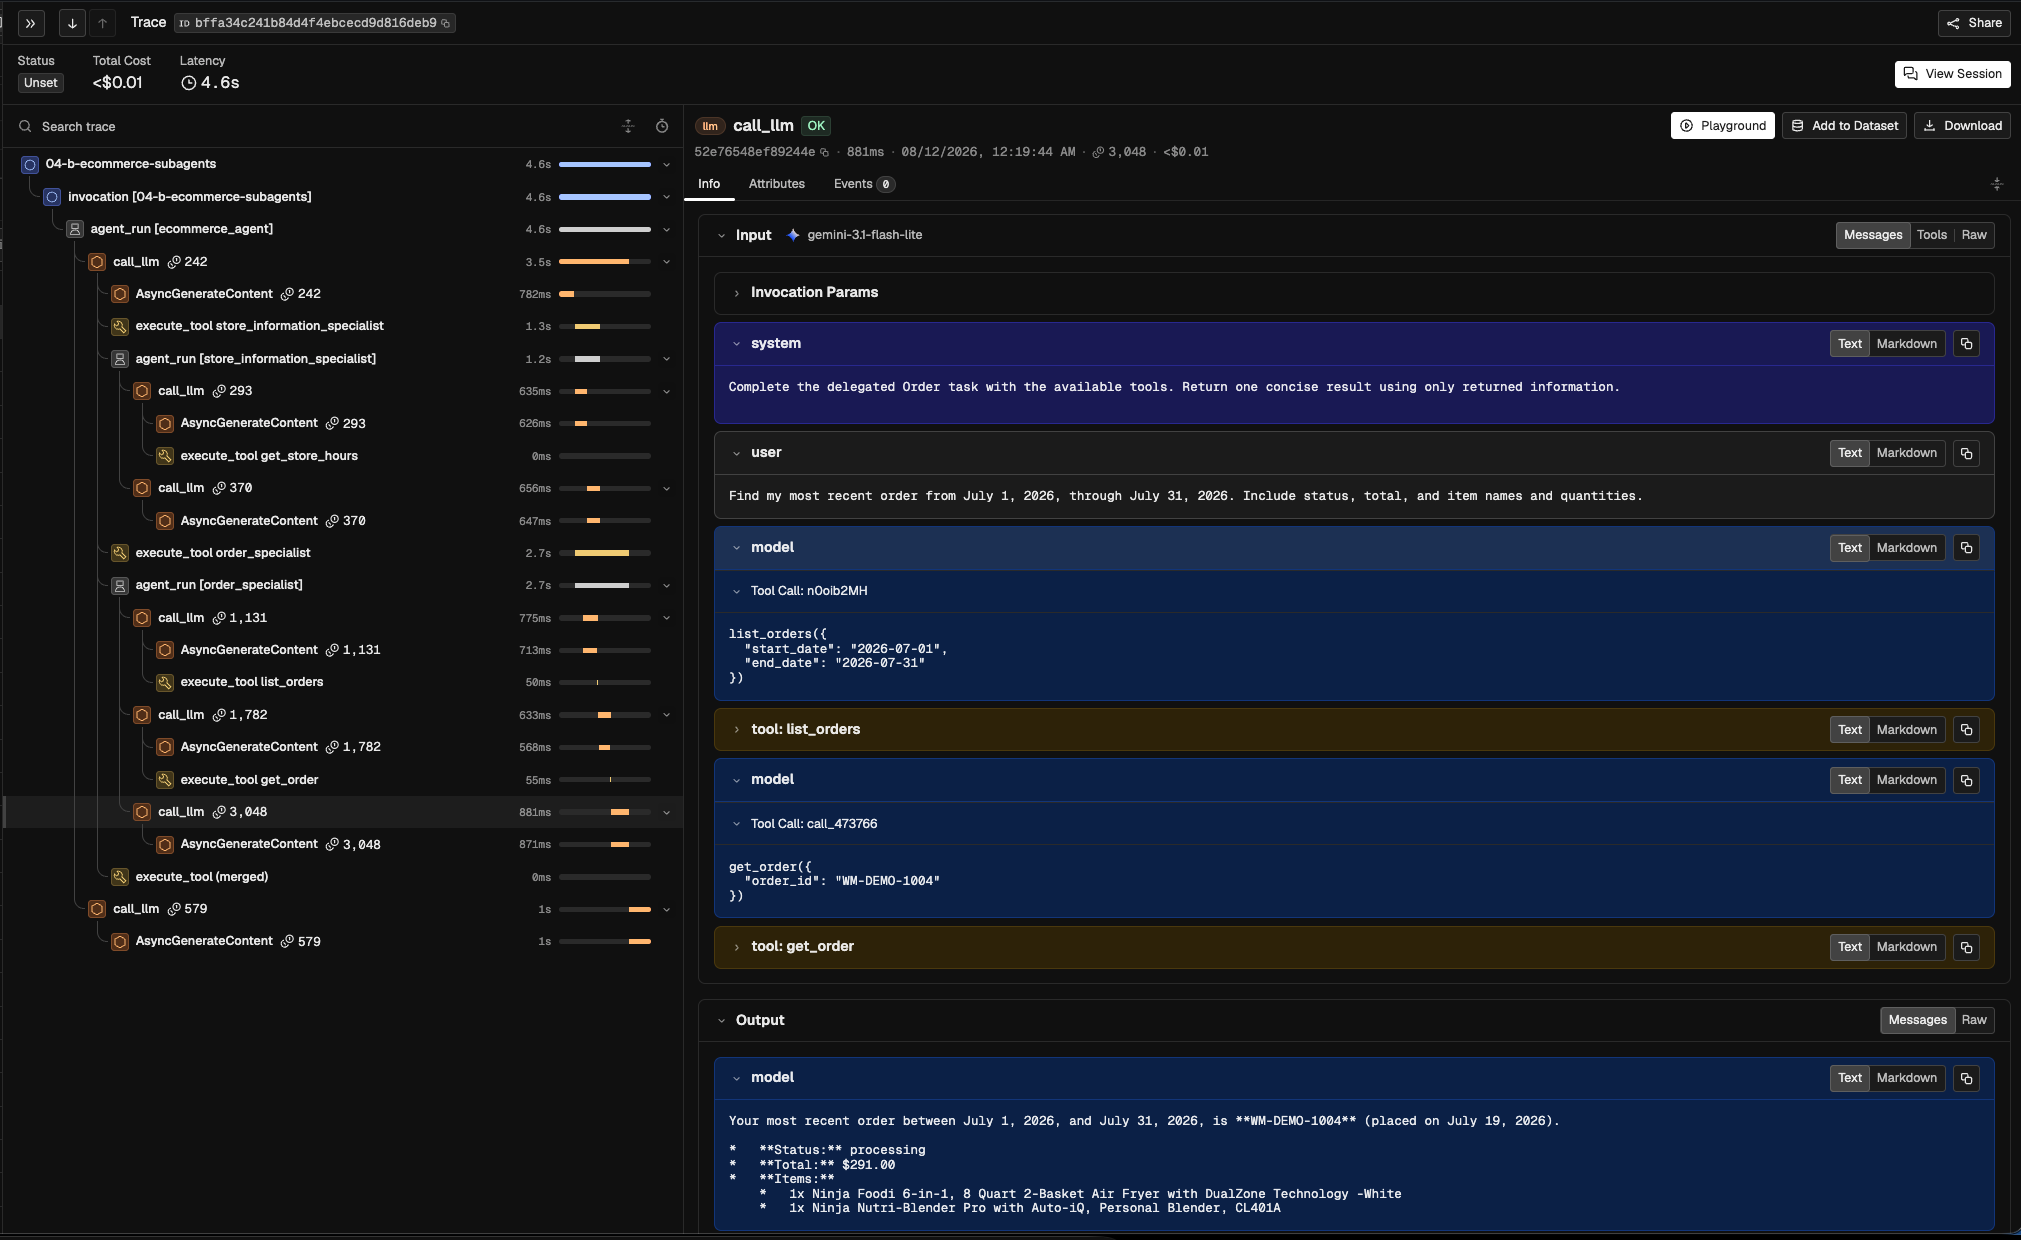

**What to notice**

The parent receives concise Store and Order results instead of inheriting either specialist's full working history.

**Takeaway:** Context separation reduces what the parent must read, at the cost of additional specialist model calls.

## 🔎 Trace flow by boundary

In [13]:
# Read the captured subagent trace as four distinct reasoning stages.
show_comparison([
    {
        "Stage": "Parent routing",
        "LLM calls": 1,
        "Tool calls": "two specialist calls",
        "Context": "Customer request",
    },
    {
        "Stage": "Store specialist",
        "LLM calls": 2,
        "Tool calls": "get_store_hours",
        "Context": "Store job only",
    },
    {
        "Stage": "Order specialist",
        "LLM calls": 3,
        "Tool calls": "list_orders → get_order",
        "Context": "Order job only",
    },
    {
        "Stage": "Parent synthesis",
        "LLM calls": 1,
        "Tool calls": "—",
        "Context": "Two bounded results",
    },
])

┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Stage            ┃ LLM calls ┃ Tool calls              ┃ Context             ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ Parent routing   │ 1         │ two specialist calls    │ Customer request    │
│ Store specialist │ 2         │ get_store_hours         │ Store job only      │
│ Order specialist │ 3         │ list_orders → get_order │ Order job only      │
│ Parent synthesis │ 1         │ —                       │ Two bounded results │
└──────────────────┴───────────┴─────────────────────────┴─────────────────────┘

The counts above describe the captured trace. Live model behavior can vary,
but the boundary remains the same: parent routing, isolated specialist work,
then parent synthesis.

## 🔎 Benefits and Trade-offs

In [14]:
# Compare shared context with separated specialist contexts.
show_comparison([
    {
        "Design": "One agent + Skills",
        "Context": "Shared",
        "Extra model boundary": "No",
        "LLM calls": skills_result.model_calls,
        "Tool calls": skills_result.tool_calls,
        "Tokens": skills_result.tokens,
        "Latency": skills_result.latency_seconds,
        "Best when": "One agent can own the work",
    },
    {
        "Design": "Parent + subagents",
        "Context": "Separate",
        "Extra model boundary": "Yes",
        "LLM calls": subagent_result.model_calls,
        "Tool calls": subagent_result.tool_calls,
        "Tokens": subagent_result.tokens,
        "Latency": subagent_result.latency_seconds,
        "Best when": "A domain needs isolation",
    },
])

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃                   ┃          ┃ Extra model      ┃           ┃            ┃        ┃         ┃                   ┃
┃ Design            ┃ Context  ┃ boundary         ┃ LLM calls ┃ Tool calls ┃ Tokens ┃ Latency ┃ Best when         ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ One agent +       │ Shared   │ No               │ 6         │ 6          │ 15057  │ 5.19    │ One agent can own │
│ Skills            │          │                  │           │            │        │         │ the work          │
│ Parent +          │ Separate │ Yes              │ 7         │ 5          │ 7439   │ 4.52    │ A domain needs    │
│ subagents         │          │                  │           │            │        │         │ isolation         │
└───────────────────┴──────────┴──────────────────┴───────────┴────────────┴────────┴─────────┴───────────────────┘

## 🔎 Trace-reading prompt

Compare which **Skills or specialist contexts** are loaded in each architecture,
then use the existing **total-token comparison** to discuss the trade-off.

## Conclusion

Choose **Skills** when one agent can own the conversation and needs focused
procedures on demand. Choose **subagents** when a domain deserves its own
prompt, tools, context, and loop—even though that adds another model boundary.

## ✅ Checkpoint

You can now explain not only *how* to build both designs, but *why* you would
choose one. That is the real architectural skill.

In [15]:
await close_mcp_tools()
print("✅ MCP connections closed cleanly")

✅ MCP connections closed cleanly
